# Q5 - Code Review_Required Capstone_12.1

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from scipy.stats import norm
from skopt import gp_minimize
from skopt.space import Real
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler

In [2]:
inputs5 = np.array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
       [0.75865295, 0.53651774, 0.65600038, 0.36034155],
       [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
       [0.70605083, 0.53419196, 0.26424335, 0.48208755],
       [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
       [0.68343225, 0.11866264, 0.82904591, 0.56757661],
       [0.55362148, 0.66734998, 0.32380582, 0.81486975],
       [0.35235627, 0.32224153, 0.11697937, 0.47311252],
       [0.15378571, 0.72938169, 0.42259844, 0.44307417],
       [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
       [0.67749115, 0.35850951, 0.47959222, 0.07288048],
       [0.58397341, 0.14724265, 0.34809746, 0.42861465],
       [0.30688872, 0.31687813, 0.62263448, 0.09539906],
       [0.51114177, 0.817957  , 0.72871042, 0.11235362],
       [0.43893338, 0.77409176, 0.37816709, 0.93369621],
       [0.22418902, 0.84648049, 0.87948418, 0.87851568],
       [0.72526172, 0.47987049, 0.08894684, 0.75976022],
       [0.35548161, 0.63961937, 0.41761768, 0.12260384],
       [0.11987923, 0.86254031, 0.64333133, 0.84980383],
       [0.12688467, 0.15342962, 0.77016219, 0.19051811],
       [0.443528, 0.710057, 0.999250, 0.985791],
       [0.459584, 0.508628, 0.762446, 0.829585],
       [0.393528, 0.760057, 1.000000, 1.000000]])

In [3]:
outputs5 = np.array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
       2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
       8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
       6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
       2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00, 2179.378101905763, 152.4047606629494,2490.371749196829])

## Surrogate function

In [4]:
X = inputs5
y = outputs5


# Define a robust kernel
kernel_best_Q5 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.5, 2.5, 2.5, 1.5], nu=2.5)
#kernel_best_Q5 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=4, length_scale_bounds=(1e-3, 1e2)) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-9, 1e-1))

#+ WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel_best_Q5,
    n_restarts_optimizer=50,
    alpha=1e-6,
    random_state=42,
    normalize_y=True)

# Fit GP
gp.fit(X, y)
print("Optimized kernel:", gp.kernel_)

Optimized kernel: 1.21**2 * Matern(length_scale=[1.49e+03, 5.42e+04, 1.38, 0.085], nu=2.5)


## Visualization - Observations

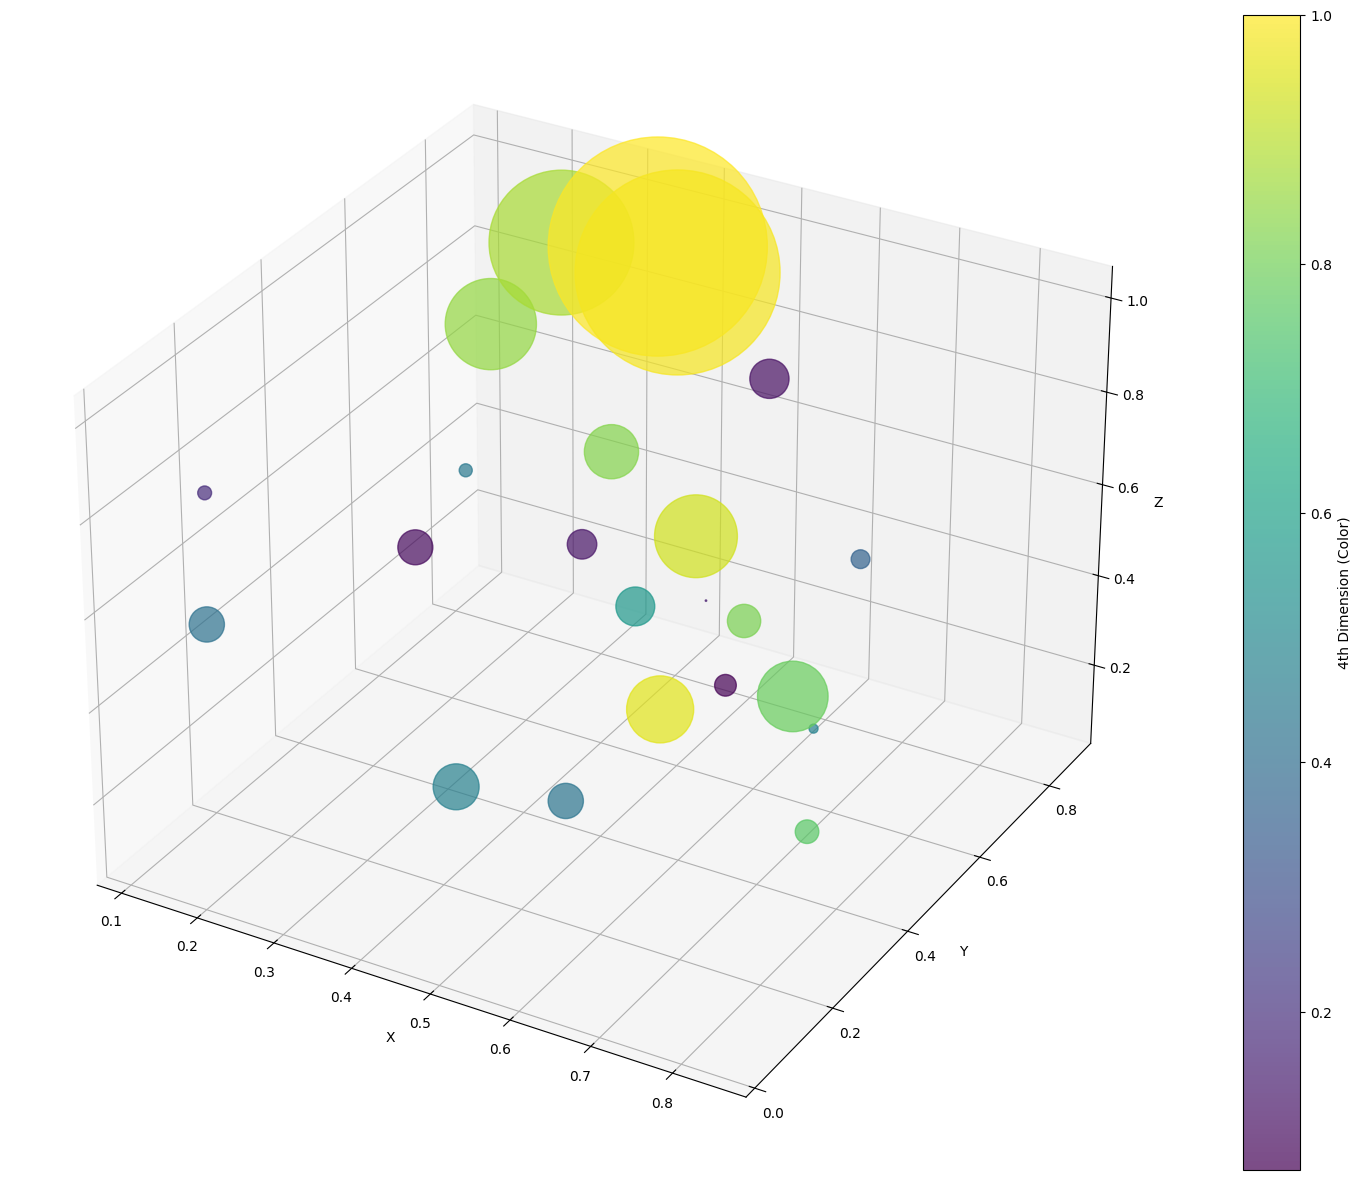

In [5]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X[:, 3], s = y*10, cmap='viridis', alpha=0.7)

#because output is difference from the baseline and the problem is related to cost saving (i.e. deduction from baseline)
#so, output is negative
#to visualize the output, adding a negative to output is needed

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Acquisition function - Local refinement

In [6]:
import numpy as np
from scipy.optimize import differential_evolution, minimize
from scipy.stats import norm

# ---------------------------
# Acquisition helpers
# ---------------------------
def hybrid_ucb(X, gp, kappa=0.1, alpha=0.5):
    mu, sigma = gp.predict(np.atleast_2d(X), return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    return alpha * mu + (1 - alpha) * (mu + kappa * sigma)

def expected_improvement(X, gp, y_best, xi=0.0):
    X = np.atleast_2d(X)
    mu, sigma = gp.predict(X, return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    with np.errstate(divide='warn'):
        Z = (mu - y_best - xi) / sigma
        ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# ---------------------------
# Utility: bounded local box around x_best
# ---------------------------
def trust_region_bounds(x_best, bounds, frac=0.1, min_width=1e-6):
    """
    Create a local box around x_best that is `frac` of the global range in each dim.
    frac: fraction of the full range to use on each side (so box width = frac * range)
    """
    bounds_arr = np.array(bounds)
    full_range = bounds_arr[:, 1] - bounds_arr[:, 0]
    half_width = np.maximum(frac * full_range / 2.0, min_width)
    local_bounds = []
    for i in range(len(bounds)):
        low = max(bounds[i][0], x_best[i] - half_width[i])
        high = min(bounds[i][1], x_best[i] + half_width[i])
        local_bounds.append((low, high))
    return local_bounds

# ---------------------------
# Stage B: local exploitation (L-BFGS-B or Nelder-Mead)
# ---------------------------
def local_refinement(x0, acquisition_func, gp, bounds_local, y_best=None,
                     method="L-BFGS-B", objective_on="EI", xi=0.0):
    """
    x0: starting point (1D array)
    acquisition_func: callable(X, gp, ...) -> acquisition values
    bounds_local: list of tuples for local box
    objective_on: "EI" or "mean" or "hybrid_ucb" - choose which objective to *maximize*
    Returns refined point and acquisition value.
    """
    dim = len(x0)

    # objective to minimize (negative acquisition)
    def obj_for_min(x):
        x = np.atleast_2d(x)
        if objective_on == "EI":
            val = expected_improvement(x, gp, y_best=y_best, xi=xi)[0]
        elif objective_on == "mean":
            mu, _ = gp.predict(x, return_std=True)
            val = mu.ravel()[0]
        elif objective_on == "hybrid_ucb":
            val = hybrid_ucb(x, gp, kappa=0.0, alpha=1.0)[0]  # pure mean
        else:
            val = acquisition_func(x, gp)[0]
        return -float(val)

    # run minimize with multiple restarts (small jitter)
    best_x = np.array(x0).copy()
    best_val = -obj_for_min(best_x)

    # attempts: base start + a few jittered starts
    starts = [best_x] + [np.clip(best_x + 1e-3 * np.random.randn(dim), 
                                 [b[0] for b in bounds_local], [b[1] for b in bounds_local])
                         for _ in range(5)]

    for s in starts:
        res = minimize(obj_for_min, s, bounds=bounds_local, method=method,
                       options={"maxiter": 200})
        if not res.success:
            # fallback: still consider evaluated point
            xcand = np.clip(res.x, [b[0] for b in bounds_local], [b[1] for b in bounds_local])
            val = -obj_for_min(xcand)
        else:
            xcand = res.x
            val = -res.fun

        if val > best_val:
            best_val = val
            best_x = xcand

    return np.asarray(best_x), float(best_val)

# ---------------------------
# Two-stage acquisition optimizer (global -> local-exploit near x_best)
# ---------------------------
def optimize_with_local_exploit(gp, bounds, x_best_obs, y_best_obs,
                                global_acq_func=hybrid_ucb,
                                global_kappa=2.0, global_n_restarts=3,
                                trust_frac=0.2,  # trust region fraction of global range
                                local_objective="EI",  # "EI" or "mean"
                                local_method="L-BFGS-B",
                                do_global=True,
                                random_seed=None):
    """
    - gp: trained GP
    - bounds: global bounds list of tuples
    - x_best_obs: the observed best point (1D-array)
    - y_best_obs: observed best y (scalar)
    - do_global: if True do a global search first (DE); otherwise only local
    """

    dim = len(bounds)
    if random_seed is not None:
        np.random.seed(random_seed)

    # Stage A: optional global search (coarse) to find candidates
    best_global_x = None
    best_global_val = -np.inf
    if do_global:
        def obj_global(x):
            return -global_acq_func(np.atleast_2d(x), gp, kappa=global_kappa)[0]

        res = differential_evolution(obj_global, bounds=bounds, maxiter=80, popsize=15, polish=True)
        best_global_x = res.x
        best_global_val = -res.fun

    # Stage B: trust-region local exploitation around the observed best
    local_bounds = trust_region_bounds(np.asarray(x_best_obs), bounds, frac=trust_frac)
    x_refined, val_refined = local_refinement(x0=np.asarray(x_best_obs),
                                              acquisition_func=global_acq_func,
                                              gp=gp,
                                              bounds_local=local_bounds,
                                              y_best=y_best_obs,
                                              method=local_method,
                                              objective_on=local_objective)

    # Decision: choose local exploitation if it has better acquisition than global candidate
    chosen_x = x_refined
    chosen_val = val_refined
    if do_global and best_global_val > val_refined:
        chosen_x = best_global_x
        chosen_val = best_global_val

    # Also return diagnostics
    diagnostics = {
        "global_candidate": best_global_x,
        "global_val": float(best_global_val) if do_global else None,
        "local_candidate": x_refined,
        "local_val": float(val_refined),
        "chosen_x": chosen_x,
        "chosen_val": float(chosen_val),
        "local_bounds": local_bounds
    }

    return np.asarray(chosen_x), float(chosen_val), diagnostics


In [16]:
# Suppose you have:
# gp = trained GaussianProcessRegressor
# x_best_obs = np.array([0.3, 0.7, 0.2, 0.6])  # your best observed point
# y_best_obs = 1.234  # best observed y

bounds = [(0,1),(0,1),(0,1),(0,1)]
x_best_obs = np.array([0.393528, 0.760057, 1.000000, 1.000000])
y_best_obs = 2490.371749196829

next_point, acq_val, diag = optimize_with_local_exploit(
    gp=gp,
    bounds=bounds,
    x_best_obs=x_best_obs,
    y_best_obs=y_best_obs,
    global_acq_func=hybrid_ucb,
    global_kappa=0.2,
    global_n_restarts=3,
    trust_frac=0.1,
    local_objective="mean",
    do_global=False,
    local_method = "Nelder-Mead"
)

print("Chosen next point:", next_point)
print("Diagnostics:", diag)


Chosen next point: [0.343528 0.810057 1.       1.      ]
Diagnostics: {'global_candidate': None, 'global_val': None, 'local_candidate': array([0.343528, 0.810057, 1.      , 1.      ]), 'local_val': 2490.36679516506, 'chosen_x': array([0.343528, 0.810057, 1.      , 1.      ]), 'chosen_val': 2490.36679516506, 'local_bounds': [(0.343528, 0.443528), (0.7100569999999999, 0.810057), (0.95, 1), (0.95, 1)]}


## Visualization - Observations + next query point

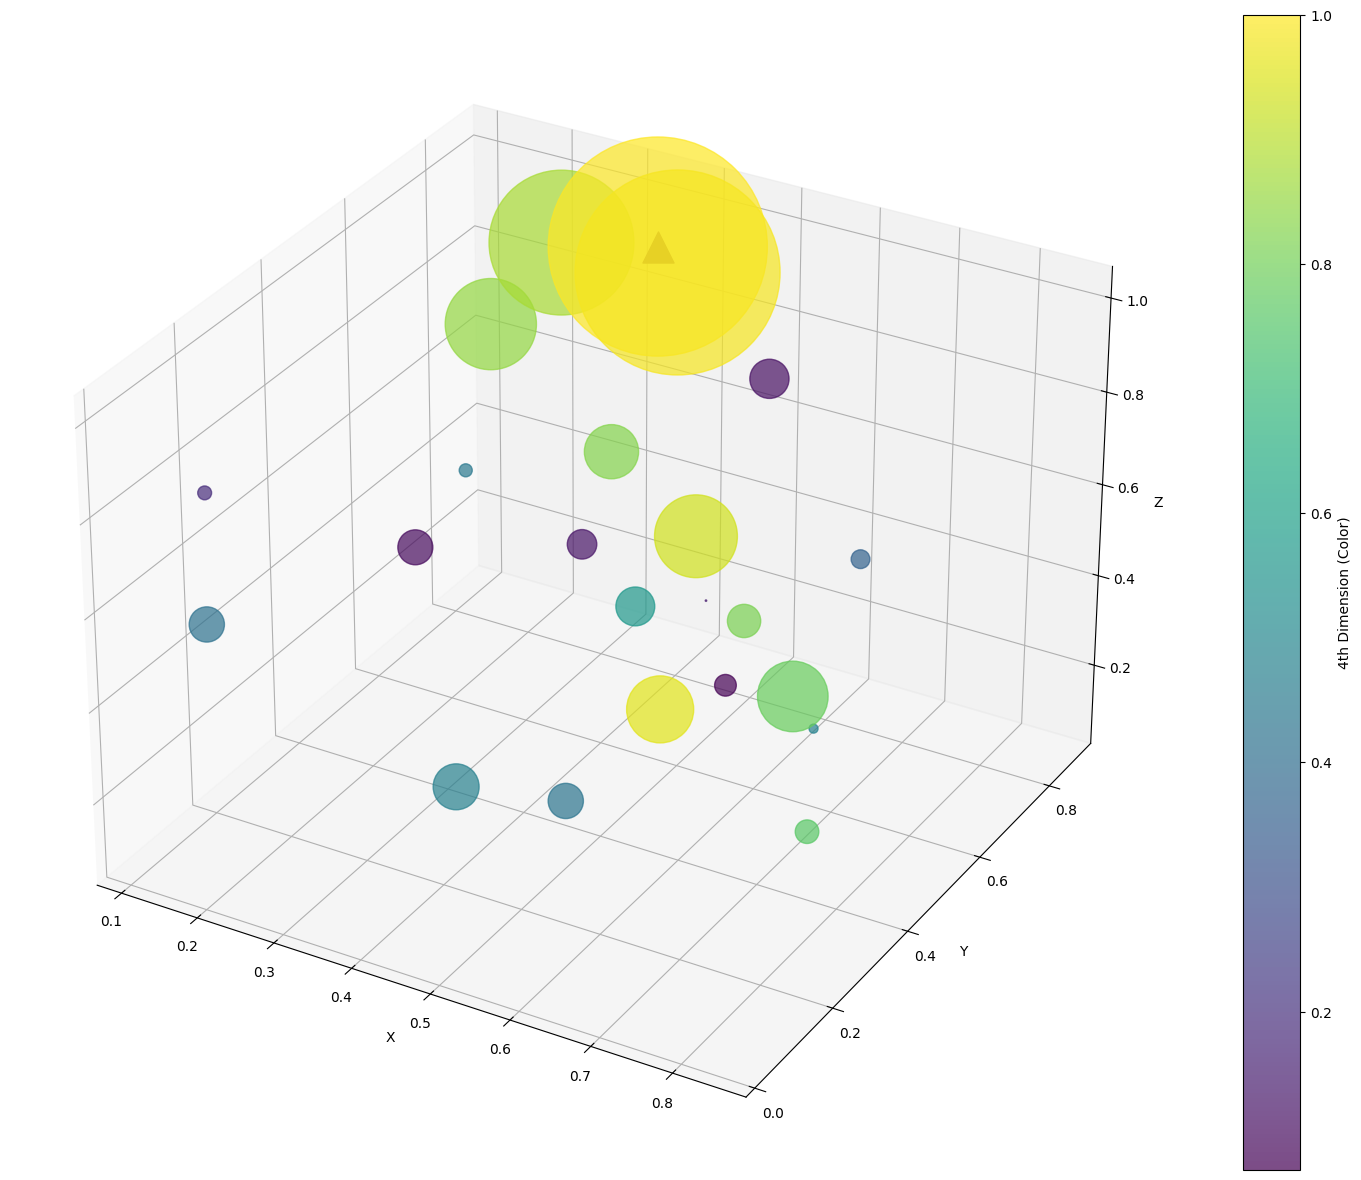

In [8]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X[:, 3], s = y*10, cmap='viridis', alpha=0.7)
#ax.scatter(next_point[0], next_point[0], next_point[0], c=next_point[0], s=500, marker="*", label="Next query")
ax.scatter(x_next[0], x_next[1], x_next[2], c=x_next[3], s=500, marker="^", label="Next query")

#because output is difference from the baseline and the problem is related to cost saving (i.e. deduction from baseline)
#so, output is negative
#to visualize the output, adding a negative to output is needed

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Predicted mean and standard deviation

In [10]:
n_candidates = 5000
X_cand = np.random.rand(n_candidates, 4)
y_mean, y_std = gp.predict(X_cand, return_std=True)

## Visualiztion - Predicted Mean

NameError: name 'next_point' is not defined

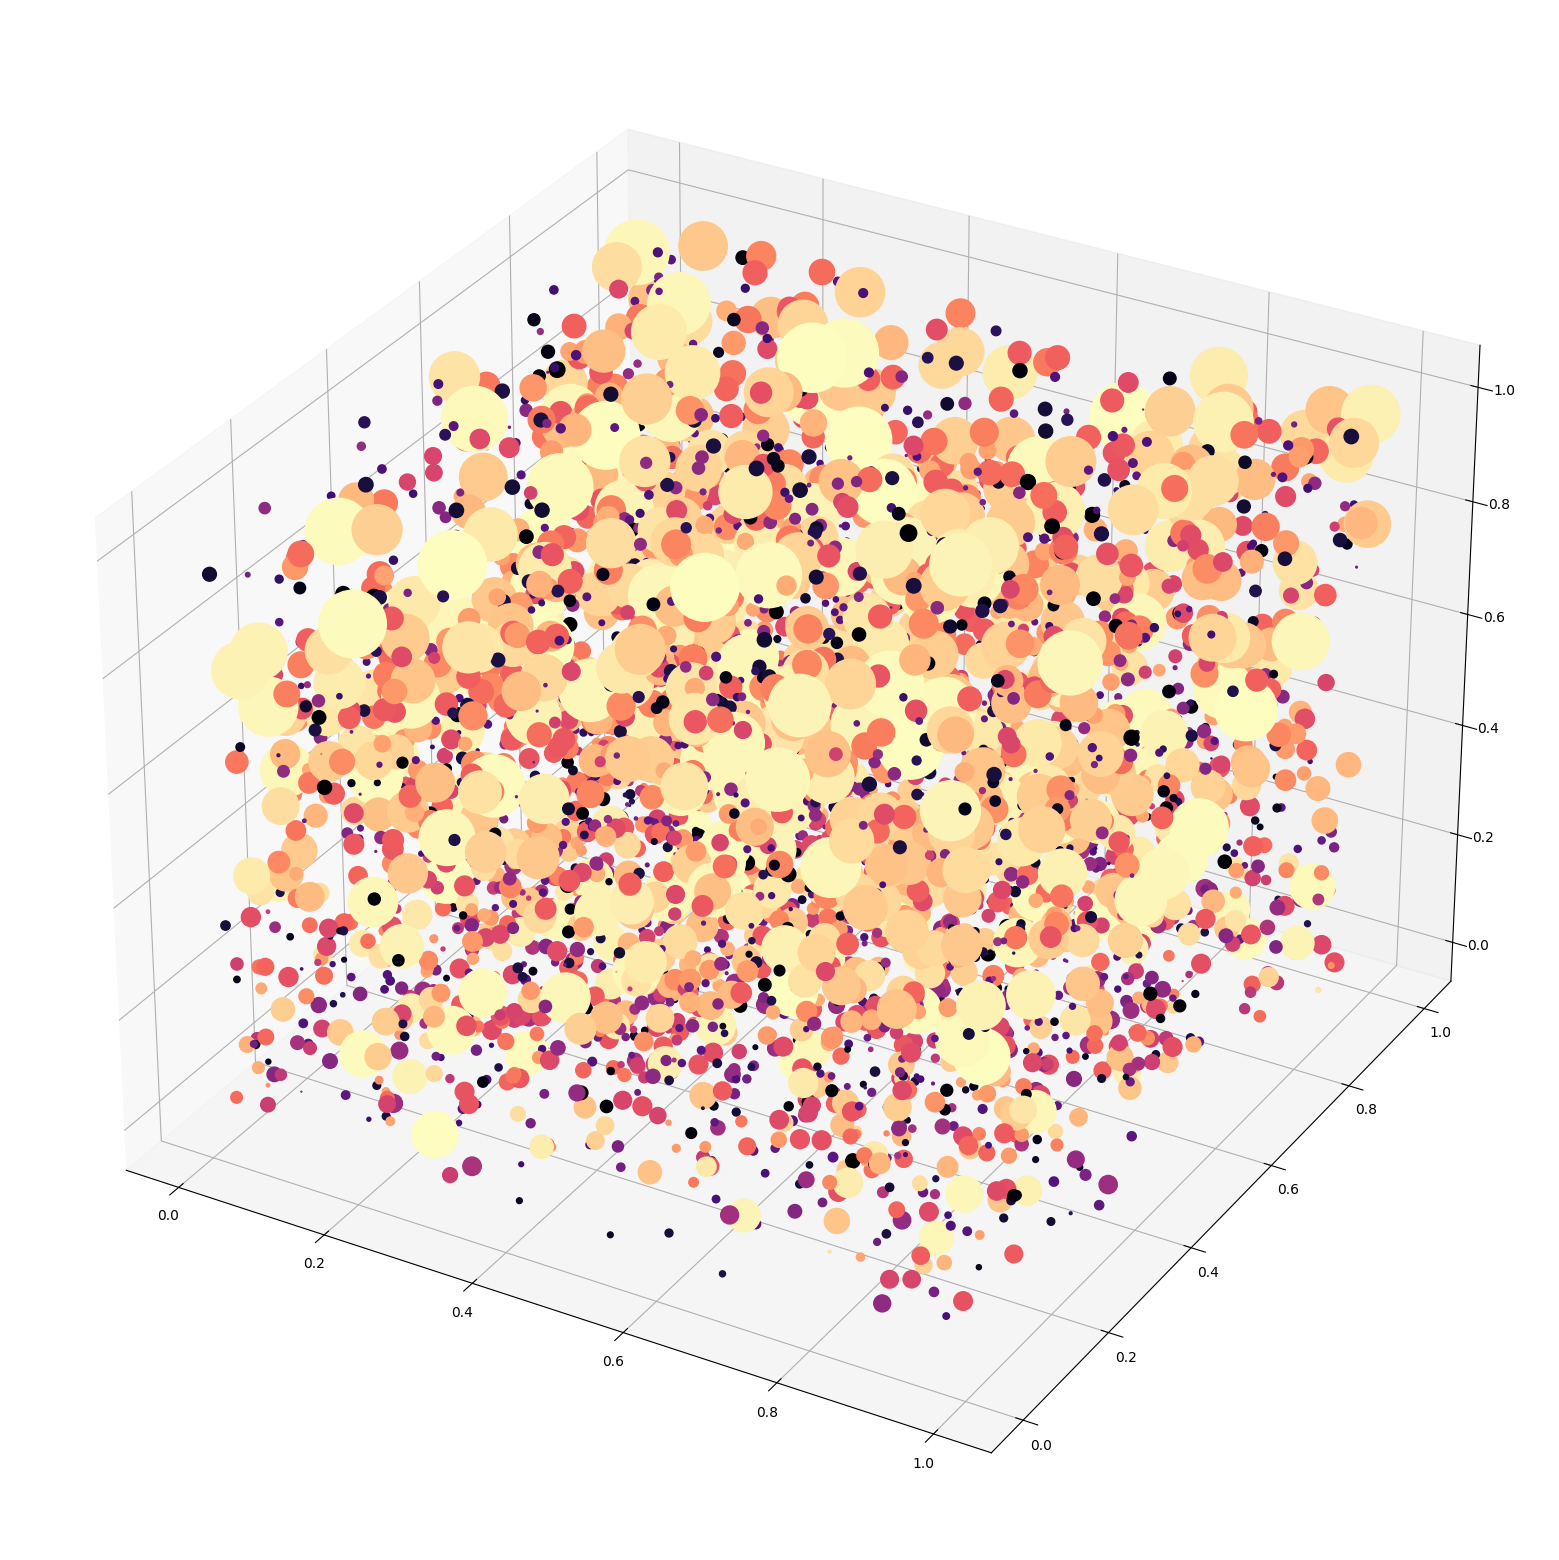

In [14]:
fig = plt.figure(figsize=(30, 20))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_cand[:, 0], X_cand[:, 1], X_cand[:, 2], c=X_cand[:, 3], s = y_mean, cmap='magma', alpha=1)
ax.scatter(next_point[0], next_point[1], next_point[2], c=next_point[3], s=10, marker="*", label="Next query")
#ax.scatter(0.443528, 0.710057, 0.999250, c=0.985791, s=100, marker="X", label="Previous query")

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Visualization - Predicted standard deviation

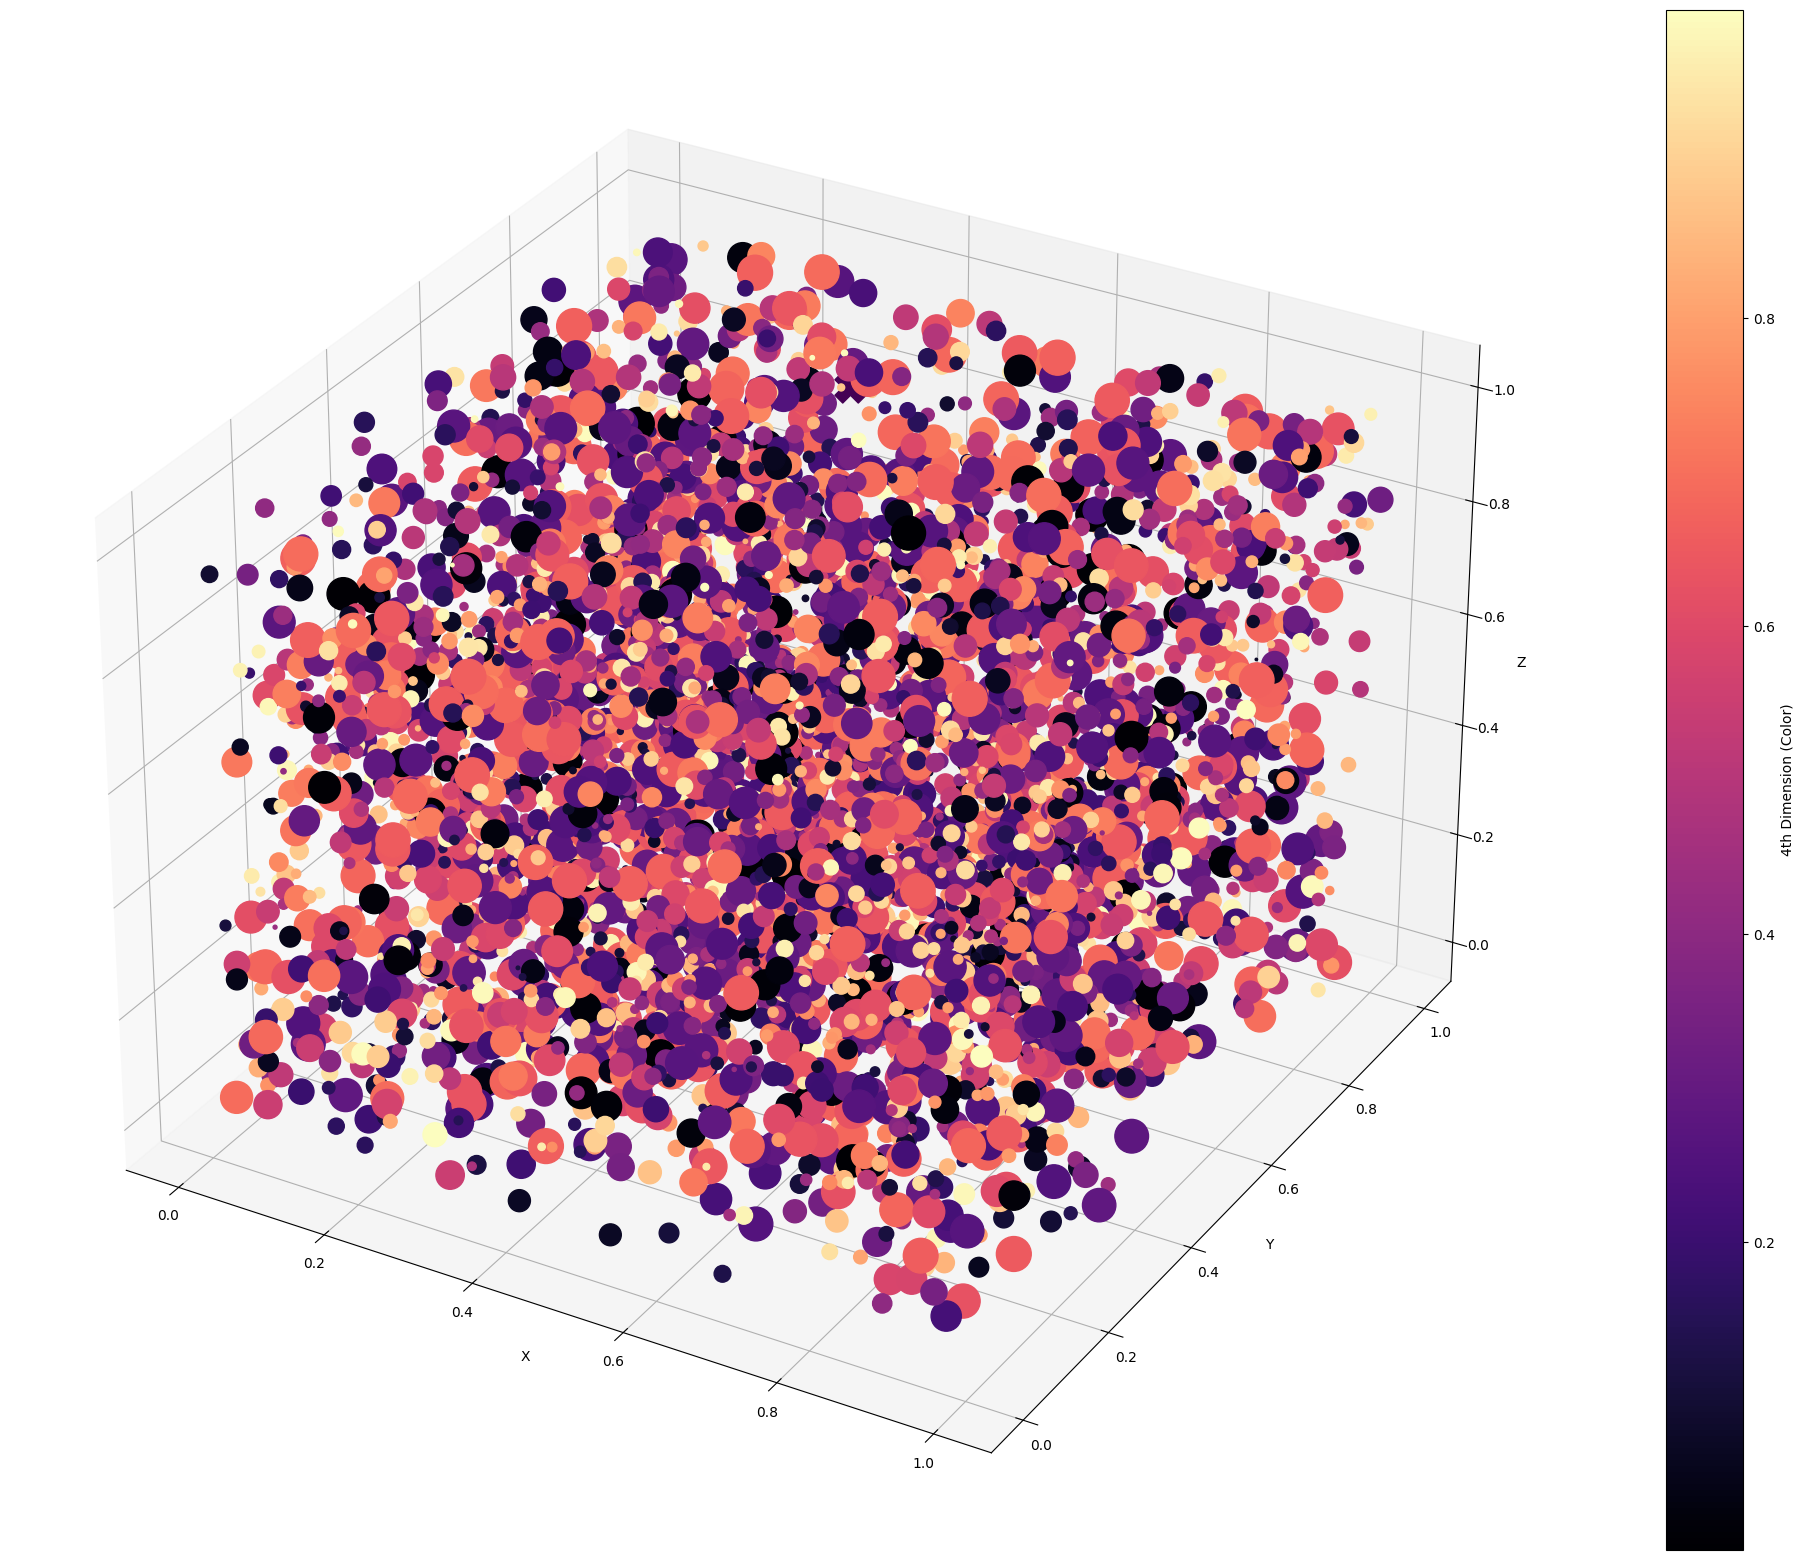

In [12]:
fig = plt.figure(figsize=(30, 20))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_cand[:, 0], X_cand[:, 1], X_cand[:, 2], c=X_cand[:, 3], s = y_std, cmap='magma', alpha=1)
#ax.scatter(next_point[0][0], next_point[0][1], next_point[0][2], c=next_point[0][3], s=500, marker="*", label="Next query")

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()